In [2]:
'''
Estimate spectrum with BHC coefficients using real data.
'''

'\nEstimate spectrum with BHC coefficients using real data.\n'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize
import SimpleITK as sitk

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.fbp import additional_fbp_filter
from pcct_md_diffusion.utils import load_nist_attenuation, load_mixture_attenuation_from_composition_file
from pcct_md_diffusion.locations import base_input_dir

In [4]:
# load material attenuation data
ich = 2  # channel to analyze
min_kev = 50
max_kev = 120
step_kev = 5
kevs = np.arange(min_kev, max_kev + 1, step_kev)

df_att, dict_density = load_mixture_attenuation_from_composition_file(
    os.path.join(base_input_dir, 'omnitom_pcd/calibration/material_composition.csv'),
    os.path.join(base_input_dir, 'spectrum/NIST'),
    kevs=kevs,
    return_density=True
)

df_water = load_nist_attenuation(
    os.path.join(base_input_dir, 'spectrum/NIST/water.txt'),
    kevs=kevs
)

df_att['true_water'] = df_water['mu']
dict_density['true_water'] = 1.0

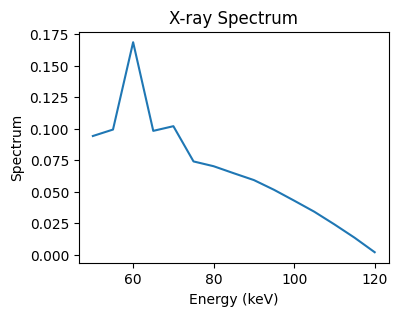

In [4]:
# load spectrum
# fist load with 1 kev step, then average to get the spectrum at the desired kevs

df_spec = pd.read_csv(os.path.join(base_input_dir, 'spectrum/xray/spektr_120kVp_Be2p0_Cu0p127_omnitom.csv'))

spectrum = [] 
for kev in kevs:
    idx = (df_spec['Energy_keV'] >= kev - (step_kev - 1) / 2) & (df_spec['Energy_keV'] < kev + (step_kev - 1) / 2)
    spectrum.append(df_spec[idx]['Photons'].values.sum() / step_kev)
spectrum = np.array(spectrum)
spectrum = spectrum / spectrum.sum()  # normalize

df_spec = pd.DataFrame({
    'energy': kevs,
    'spectrum': spectrum
})

plt.figure(figsize=(4, 3))
plt.plot(df_spec['energy'], df_spec['spectrum'])
plt.xlabel('Energy (keV)')
plt.ylabel('Spectrum')
plt.title('X-ray Spectrum')
plt.show()

Loading channel 0...
Loading channel 1...
Loading channel 2...


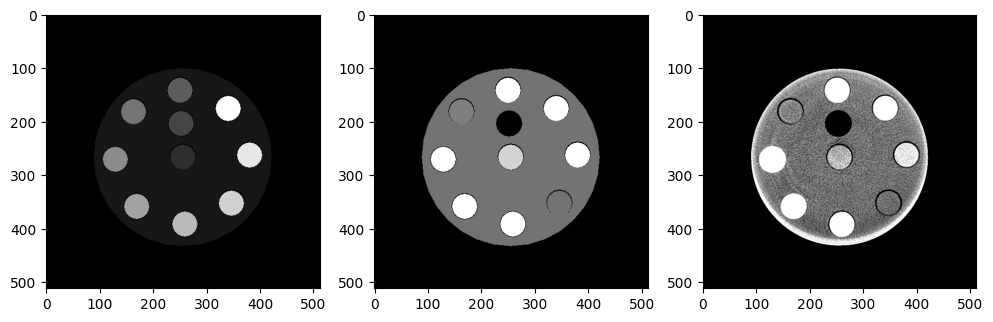

In [5]:
# load mask phantom
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
dx, dy, dz = sitk_mask.GetSpacing()
mask = sitk.GetArrayFromImage(sitk_mask)[[0]]

# load phantom material labels
df_mask = pd.read_csv(os.path.join(calibration_dir, 'materials.csv'))

# compose a 60keV phantom
img_mono_60 = np.zeros_like(mask, dtype=np.float32)
for _, row in df_mask.iterrows():
    label = row['Seg']
    material = row['Material']
    mu = df_att[df_att['energy'] == 60][material].values[0]
    img_mono_60[mask == label] = mu

# water attenuation at 60keV
mu_water_60 = df_att[df_att['energy'] == 60]['true_water'].values[0]

# load real phantom
imgs, _, _, _ = utils.load_image(calibration_dir)
imgs = imgs[:, [0], ...]

mu_waters = mu_waters = np.array([0.0196, 0.0192, 0.0186])
display_vmins = (-50 + 1000) / 1000 * mu_waters
display_vmaxs = (50 + 1000) / 1000 * mu_waters

imgs[imgs < -1000] = -1000
imgs = (imgs + 1000) / 1000 * mu_waters[:, None, None, None]
imgs = imgs.astype(np.float32)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 3, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

plt.subplot(1, 3, 3)
plt.imshow(imgs[ich, 0], 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [6]:
# forward projection
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = imgs.shape[-1]
geo.ny = imgs.shape[-2]
geo.nz = imgs.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
leapct = utils.set_leapct_geometry(geo)
# geo.nu *= 2
# geo.du /= 2
# geo.nview = 720
# geo.off_u = 0
# leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180.0 / geo.nview).astype(np.float32))
leapct.print_parameters()


======== CT Parallel-Beam Geometry ========
number of angles: 1440
number of detector elements (rows, cols): 1 x 878
angular range: 360.000000 degrees
detector pixel size: 5.656000 mm x 0.351570 mm
center detector pixel: 0.000000, 445.750000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-2.828000, 2.828000]

======== Processing Settings ========
GPU processing on devices 0, 1
GPU with least amount of memory: 35.170753 GB



True

Forward projecting...
Channel 0
Channel 1
Channel 2
Reconstructing...
Channel 0


Channel 1
Channel 2


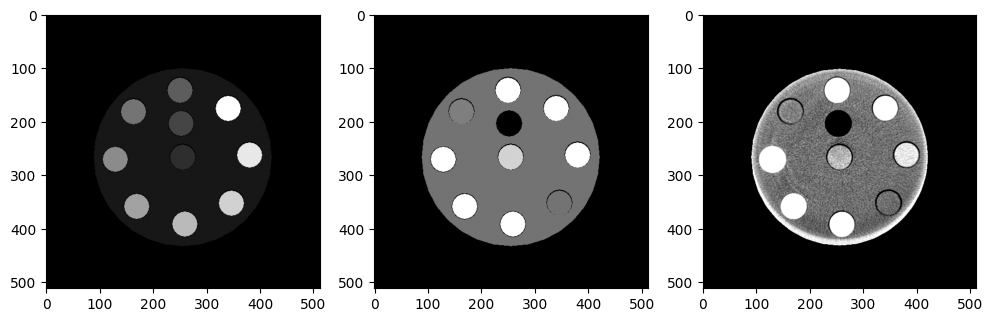

In [7]:
# cut off the area outside the phantom (foam) then do forward projection
phantom_mask = np.where(mask > 0, 1, 0)
# fill hole slice by slice
for i in range(phantom_mask.shape[0]):
    phantom_mask[i] = scipy.ndimage.binary_fill_holes(phantom_mask[i])

# set to air outside the phantom
imgs_masked = imgs.copy()
for ch in range(imgs.shape[0]):
    imgs_masked[ch] = np.where(phantom_mask > 0, imgs[ch], 0)

# forward projection
print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs = []
for ch in range(imgs_masked.shape[0]):
    print('Channel', ch, flush=True)
    leapct.project(current_fp, imgs_masked[ch])
    prjs.append(np.copy(current_fp, 'C'))
prjs = np.array(prjs)

# reconstruction
print('Reconstructing...', flush=True)
fbps = []
for ch in range(prjs.shape[0]):
    print('Channel', ch, flush=True)
    current_fbp = leapct.FBP(prjs[ch])
    fbps.append(np.copy(current_fbp, 'C'))
fbps = np.array(fbps)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(mask[0], 'gray')

plt.subplot(1, 3, 2)
plt.imshow(img_mono_60[0], 'gray', vmin=mu_water_60-0.001, vmax=mu_water_60 + 0.001)

plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], 'gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [8]:
# forward project each material and make the ploychromatic projection
current_fp = leapct.allocate_projections()
prjs_materials = []
for i in range(len(df_mask)):
    label = df_mask.loc[i, 'Seg']
    material = df_mask.loc[i, 'Material']
    img_material = np.where(mask == label, 1, 0).astype(np.float32)
    _ = leapct.project(current_fp, img_material)
    prjs_materials.append(current_fp.copy())
prjs_materials = np.array(prjs_materials)

# the attenuation coefficient of each material at each energy
mus_materials = []
for i in range(len(df_mask)):
    material = df_mask.loc[i, 'Material']
    mus_materials.append(df_att[material].values)
mus_materials = np.array(mus_materials)

# compute the polychromatic projection
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs_poly_simul = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1)).astype(np.float32)

[ 9.60890083e-01  4.18876045e-03 -1.86090090e-05]


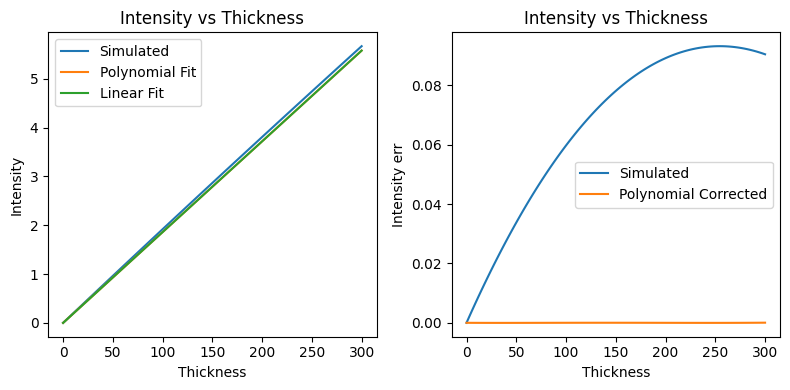

In [9]:
# initialize BHC coefficients with simulation
thicknesses = np.linspace(0, 300, 100)  # mm
attenuation = df_att['water'].values * thicknesses[:, None]
intensity = -np.log(np.sum(spectrum * np.exp(-attenuation), axis=-1))
intensity[intensity < 0] = 0

# expected water attenuation: fit with y = kx
# water_att = np.linalg.lstsq(thicknesses[:, None], intensity, rcond=None)[0][0]
# print(f'Fitted water attenuation: {water_att:.6f}, True water attenuation at 60keV: {mu_water_60:.6f}')

# use 3-order polynomial fit without intercept
poly_order = 3
A = np.vstack([intensity**i for i in range(1, poly_order + 1)]).T
b = mu_waters[ich] * thicknesses
coeffs = np.linalg.lstsq(A, b, rcond=None)[0]
print(coeffs)

# apply polynomial BHC
intensity_fit = np.sum(coeffs[:, None] * np.vstack([intensity**i for i in range(1, poly_order + 1)]), axis=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, intensity_fit, label='Polynomial Fit')
plt.plot(thicknesses, mu_waters[ich] * thicknesses, label='Linear Fit')
plt.xlabel('Thickness')
plt.ylabel('Intensity')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(thicknesses, intensity - mu_waters[ich] * thicknesses, label='Simulated')
plt.plot(thicknesses, intensity_fit - mu_waters[ich] * thicknesses, label='Polynomial Corrected')
plt.xlabel('Thickness')
plt.ylabel('Intensity err')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.show()

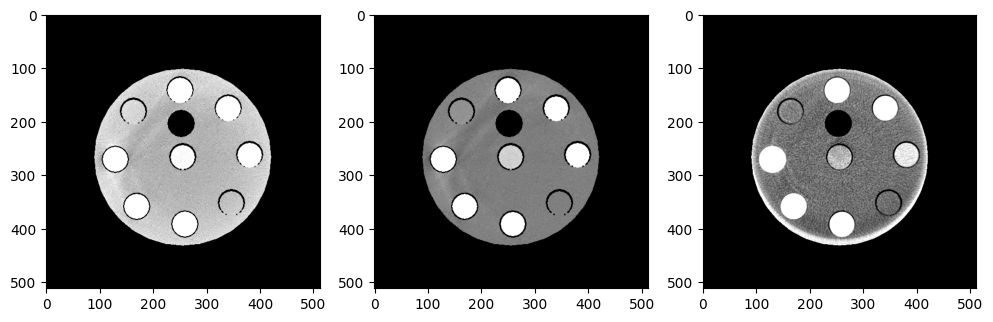

In [10]:
# apply correction to the projection data
prjs_fit_simul = np.sum(coeffs[:, None, None, None] * np.array([prjs_poly_simul**i for i in range(1, poly_order + 1)]), axis=0).astype(np.float32)
prjs_fit_simul = additional_fbp_filter(prjs_fit_simul)
recon_fit_simul = leapct.FBP(prjs_fit_simul)

recon_poly_simul = leapct.FBP(prjs_poly_simul)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_poly_simul[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_fit_simul[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

In [11]:
def poly_forward_with_bhc(s, c, material_matrix):
    '''
    s: (n_energy,) spectrum logits before softmax
    c: (poly_order,) polynomial coefficients
    material_matrix: (n_samples, n_energy) the effective attenuation of each sample at each energy
    '''
    # softmax to ensure positivity and sum to 1
    s = np.exp(s) / np.sum(np.exp(s))

    fp = -np.log(material_matrix @ s)
    return np.sum(c[:, None] * np.array([fp**i for i in range(1, len(c) + 1)]), axis=0)


def derivative_poly_forward_with_bhc(s, c, material_matrix):
    '''
    derivative of poly_forward_with_bhc with respect to logits s
    '''
    softmax_s = np.exp(s) / np.sum(np.exp(s))
    att_matrix = material_matrix @ softmax_s  # (n_samples,)

    poly_term = np.sum(c[:, None] * np.array([i * (-np.log(att_matrix))**(i-1) for i in range(1, len(c) + 1)]), axis=0)  # (n_samples,)
    d_fp_d_s = 1 / (-att_matrix[:, None]) * (material_matrix - att_matrix[:, None]) * softmax_s[None, :]  # (n_samples, n_energy)

    return poly_term[:, None] * d_fp_d_s


def mse_loss(s, c, material_matrix, y):
    '''
    MSE loss between poly_forward_with_bhc and y
    '''
    pred = poly_forward_with_bhc(s, c, material_matrix)
    return np.mean((pred - y)**2)


def derivative_mse_loss_with_respect_to_s(s, c, material_matrix, y):
    '''
    derivative of MSE loss with respect to logits s
    '''
    pred = poly_forward_with_bhc(s, c, material_matrix)
    d_pred_d_s = derivative_poly_forward_with_bhc(s, c, material_matrix)
    return 2 * np.sum((pred - y)[:, None] * d_pred_d_s, axis=0) / len(y)

In [12]:
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
attenuation = attenuation.reshape([-1, attenuation.shape[-1]]).astype(np.float32)

# keep only the non-air rows
inds = attenuation.max(axis=1) > 1e-4
material_matrix = np.exp(-attenuation[inds])

y = prjs[ich].reshape(-1)[inds]

[ 9.9644774e-01 -5.6074583e-03  4.6884568e-04]


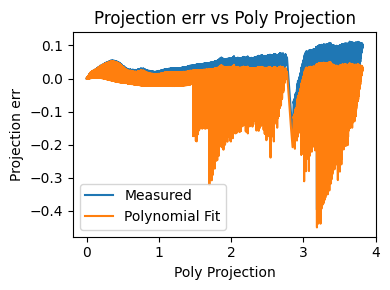

In [13]:
# fit coefficients with water-only projections(water, water_base, true_water, brain, adipose)
water_materials = ['water', 'water_base', 'true_water', 'brain', 'adipose']
df_mask_exclusion = df_mask[~df_mask['Material'].isin(water_materials)].copy()
prjs_exclusion_mask = np.where(np.sum(prjs_materials[df_mask_exclusion.index] , axis=0), 1, 0)

df_mask_inclusion = df_mask[df_mask['Material'].isin(water_materials)].copy()
densities = np.array([dict_density[mat] for mat in df_mask_inclusion['Material']])
prjs_thickness = np.sum(prjs_materials[df_mask_inclusion.index] * densities[:, None, None, None], axis=0)

# valid data for curve fitting
inds_water_fit = np.where((prjs_thickness > 1e-4) & (prjs_exclusion_mask == 0))

measured_poly_simul_water = prjs_poly_simul[inds_water_fit]
measured_prjs_water = prjs[ich][inds_water_fit]

sort_inds = np.argsort(measured_poly_simul_water)
measured_poly_simul_water = measured_poly_simul_water[sort_inds]
measured_prjs_water = measured_prjs_water[sort_inds]

fit_coeffs = np.linalg.lstsq(np.vstack([measured_poly_simul_water**i for i in range(1, poly_order + 1)]).T, measured_prjs_water, rcond=None)[0]
print(fit_coeffs)

intensity_fit = np.sum(fit_coeffs[:, None] * np.vstack([measured_poly_simul_water**i for i in range(1, poly_order + 1)]), axis=0)

plt.figure(figsize=(4, 3))
plt.plot(measured_poly_simul_water, measured_poly_simul_water - measured_prjs_water, label='Measured')
plt.plot(measured_poly_simul_water, intensity_fit - measured_prjs_water, label='Polynomial Fit')
plt.xlabel('Poly Projection')
plt.ylabel('Projection err')
plt.title('Projection err vs Poly Projection')
plt.legend()
plt.tight_layout()

In [14]:
# joint estimation of spectrum and polynomial coefficients
sampling_factor = 1
n_outer_iter = 10
n_inner_iter = 5

s0 = np.log(spectrum + 1e-8)  # add small value to avoid log(0)
s0 = s0[::sampling_factor]
mat_matrix_sparse = material_matrix[:, ::sampling_factor]

s = s0
c = coeffs

for i_outer in range(n_outer_iter):
    print(f'Outer iteration {i_outer + 1}/{n_outer_iter}')

    # optimize spectrum with current polynomial coefficients
    res = scipy.optimize.minimize(
        fun=mse_loss,
        x0=s,
        args=(c, mat_matrix_sparse, y),
        jac=derivative_mse_loss_with_respect_to_s,
        method='L-BFGS-B',
        options={'maxiter': n_inner_iter, 'disp': True}
    )

    # solve for polynomial coefficients with current spectrum
    current_spectrum = np.exp(s) / np.sum(np.exp(s))
    fp = -np.log(mat_matrix_sparse @ current_spectrum)
    c = np.linalg.lstsq(np.array([fp**i for i in range(1, poly_order + 1)]).T, y, rcond=None)[0]

    print(f'Current coefficients: {c}')
    print(res)

    s = res.x

spectrum_estimated = np.exp(s) / np.sum(np.exp(s))
coeffs_estimated = c

Outer iteration 1/10
Current coefficients: [ 1.01143335 -0.01556886  0.00229365]
  message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  success: False
   status: 1
      fun: 0.0017700217096498605
        x: [-1.994e+00 -2.131e+00 ... -4.304e+00 -6.156e+00]
      nit: 5
      jac: [ 1.836e-04  1.342e-04 ... -3.941e-05 -6.852e-06]
     nfev: 8
     njev: 8
 hess_inv: <15x15 LbfgsInvHessProduct with dtype=float64>
Outer iteration 2/10
Current coefficients: [ 0.99951072 -0.01531241  0.00229481]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.0016678918690124396
        x: [-2.241e+00 -2.287e+00 ... -4.265e+00 -6.149e+00]
      nit: 1
      jac: [ 5.455e-06  2.076e-07 ...  2.567e-07  3.510e-08]
     nfev: 3
     njev: 3
 hess_inv: <15x15 LbfgsInvHessProduct with dtype=float64>
Outer iteration 3/10
Current coefficients: [ 1.0106855  -0.01550659  0.00233085]
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   

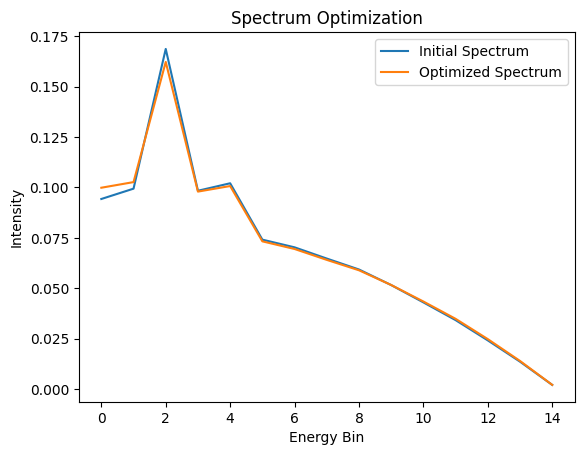

In [15]:
spectrum0 = np.exp(s0) / np.sum(np.exp(s0))

plt.plot(spectrum0, label='Initial Spectrum')
plt.plot(spectrum_estimated, label='Optimized Spectrum')
plt.xlabel('Energy Bin')
plt.ylabel('Intensity')
plt.title('Spectrum Optimization')
plt.legend()
plt.show()

[ 9.60144287e-01  4.28501859e-03 -1.97732579e-05]


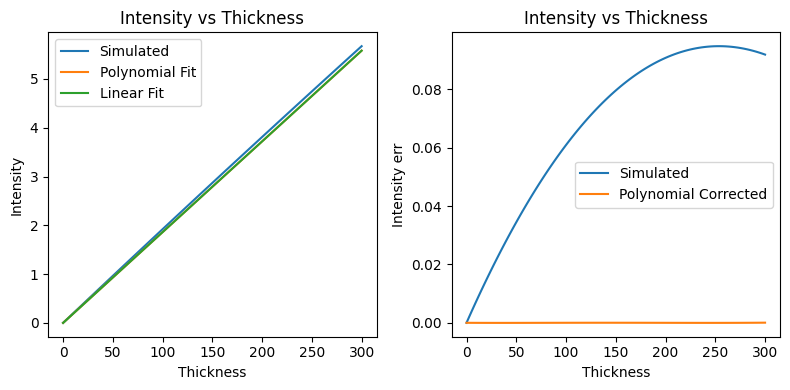

In [16]:
# reesimtate coefficients with the estimated spectrum
thicknesses = np.linspace(0, 300, 100)  # mm
attenuation = df_att['water'].values * thicknesses[:, None]
intensity = -np.log(np.sum(spectrum_estimated * np.exp(-attenuation), axis=-1))
intensity[intensity < 0] = 0

# expected water attenuation: fit with y = kx
# water_att = np.linalg.lstsq(thicknesses[:, None], intensity, rcond=None)[0][0]
# print(f'Fitted water attenuation: {water_att:.6f}, True water attenuation at 60keV: {mu_water_60:.6f}')

# use 3-order polynomial fit without intercept
poly_order = 3
A = np.vstack([intensity**i for i in range(1, poly_order + 1)]).T
b = mu_waters[ich] * thicknesses
coeffs2 = np.linalg.lstsq(A, b, rcond=None)[0]
print(coeffs2)

# apply polynomial BHC
intensity_fit = np.sum(coeffs2[:, None] * np.vstack([intensity**i for i in range(1, poly_order + 1)]), axis=0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(thicknesses, intensity, label='Simulated')
plt.plot(thicknesses, intensity_fit, label='Polynomial Fit')
plt.plot(thicknesses, mu_waters[ich] * thicknesses, label='Linear Fit')
plt.xlabel('Thickness')
plt.ylabel('Intensity')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(thicknesses, intensity - mu_waters[ich] * thicknesses, label='Simulated')
plt.plot(thicknesses, intensity_fit - mu_waters[ich] * thicknesses, label='Polynomial Corrected')
plt.xlabel('Thickness')
plt.ylabel('Intensity err')
plt.title('Intensity vs Thickness')
plt.legend()
plt.tight_layout()

plt.show()

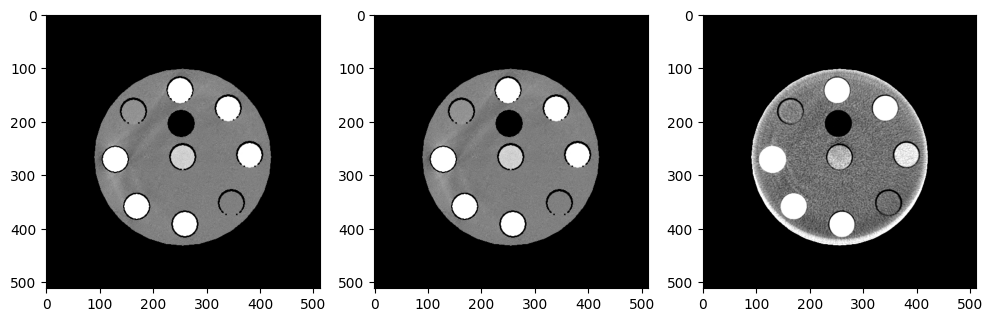

In [17]:
attenuation = np.sum(prjs_materials[..., None] * mus_materials[:, None, None, None, :], axis=0)
prjs_poly_est = -np.log(np.sum(spectrum_estimated * np.exp(-attenuation), axis=-1)).astype(np.float32)

prjs_poly_est = np.sum(coeffs2[:, None, None, None] * np.array([prjs_poly_est**i for i in range(1, poly_order + 1)]), axis=0).astype(np.float32)
prjs_poly_est = additional_fbp_filter(prjs_poly_est)
recon_fit_est = leapct.FBP(prjs_poly_est)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(recon_fit_simul[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 2)
plt.imshow(recon_fit_est[0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.subplot(1, 3, 3)
plt.imshow(fbps[ich, 0], cmap='gray', vmin=display_vmins[ich], vmax=display_vmaxs[ich])
plt.show()

MSE before correction: 1.0418605e-06
MSE after correction: 1.0418696e-06


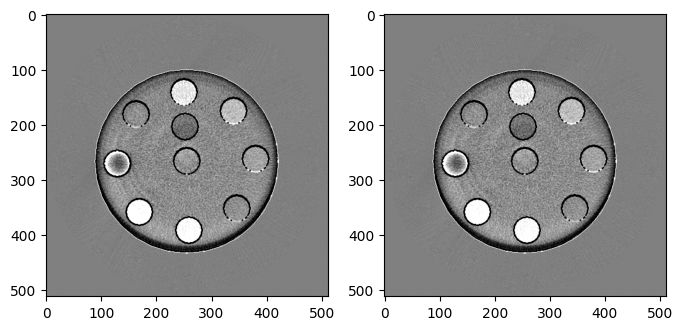

In [18]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(recon_fit_simul[0] - fbps[ich, 0], cmap='gray', vmin=-0.001, vmax=0.001)
plt.subplot(1, 2, 2)
plt.imshow(recon_fit_est[0] - fbps[ich, 0], cmap='gray', vmin=-0.001, vmax=0.001)

print('MSE before correction:', np.mean((recon_fit_simul[0] - fbps[ich, 0])**2))
print('MSE after correction:', np.mean((recon_fit_est[0] - fbps[ich, 0])**2))

In [19]:
recon_fit_hu = (recon_fit_simul / mu_waters[ich] * 1000 - 1000).astype(np.int16)
sitk_recon = sitk.GetImageFromArray(recon_fit_hu)
sitk_recon.SetSpacing(sitk_mask.GetSpacing())
sitk_recon.SetOrigin(sitk_mask.GetOrigin())
sitk_recon.SetDirection(sitk_mask.GetDirection())
sitk.WriteImage(sitk_recon, os.path.join(calibration_dir, f'recon_fit_{ich}.nii.gz'))